# 🤖⏱️ Chronos Time‑Series Forecasting

**What you'll learn**
- 🧠 What **Chronos** models do (foundation model for time series)  
- 📥 Data preparation (context window & horizon)  
- 🧰 Tokenization / scaling tips  
- ⚙️ Inference: quantiles, samples, temperature  
- 🖥️ Devices & precision (CPU/GPU/float16/bfloat16)  
- 📏 Metrics & backtesting  
- 🚀 Practical tips for energy loads (daily/weekly cycles)

## 🤖 Chronos in Simple Words

Chronos is a **pretrained time‑series foundation model**.  
You feed a **context window** (past values), and it **generates future steps**.  
It can produce **probabilistic forecasts** via **sampling** and return **quantiles** (e.g., P10/P50/P90).

### Key knobs
- **context_length**: how much history you pass in  
- **prediction_length / horizon**: how far ahead to forecast  
- **num_samples**: more samples → better quantile estimates  
- **temperature / top‑p**: sampling diversity (optional)

In [ ]:
pip install chronos-forecasting

## 🛠️ Setup & Imports

We use **PyTorch** for tensors/devices, and Chronos APIs (tokenizer/model) for forecasting.  
Keep versions pinned for reproducibility (especially CUDA/torch versions).

## 📏 Metrics (Deterministic & Probabilistic)

- **MAE / RMSE / MAPE** for point forecasts  
- **Pinball loss** for quantiles, **CRPS** for distribution quality  
- **Coverage**: share of actuals inside P10–P90 band

## 📊 Plots & Diagnostics

- Actual vs **P50** with **P10–P90** band  
- Residuals over time (drift?)  
- Error by **hour/DoW/temp** to expose missed structure

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error

import torch
from chronos import BaseChronosPipeline

import warnings
warnings.filterwarnings('ignore')

# Read datasets

## 📥 Load & Prepare Data

- Parse timestamps to **DatetimeIndex**  
- Set a clear **frequency** (e.g., hourly `H`)  
- Ensure units are documented (e.g., **kW** or **kWh**)  
- Split into **context** (history) and **forecast horizon**

## 🕒 Time Index & Frequency

Keep a consistent **frequency** and **timezone** (UTC is often simplest for modeling).  
Handle DST carefully; resample to a regular grid if needed.

In [ ]:
dataset = pd.read_csv('data/kaggle_competition_dataset.csv',
            parse_dates=['time'])
dataset.set_index('time', inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8592 entries, 2021-09-01 00:00:00 to 2022-08-24 23:00:00
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temp         8592 non-null   float64
 1   dwpt         8592 non-null   float64
 2   rhum         8592 non-null   float64
 3   prcp         2159 non-null   float64
 4   snow         119 non-null    float64
 5   wdir         8592 non-null   float64
 6   wspd         8592 non-null   float64
 7   wpgt         8592 non-null   float64
 8   pres         8592 non-null   float64
 9   coco         8396 non-null   float64
 10  el_price     8592 non-null   float64
 11  consumption  8592 non-null   float64
dtypes: float64(12)
memory usage: 872.6 KB


# Features


In [ ]:
demand = dataset[['consumption']]
demand = demand.rename(columns = {'consumption':'demand'})
demand.head()

,demand
time,
2021-09-01 00:00:00,0.577
2021-09-01 01:00:00,0.594
2021-09-01 02:00:00,0.685
2021-09-01 03:00:00,1.016
2021-09-01 04:00:00,0.677


In [ ]:
# Extract the numeric values
series = demand['demand'].values

# Forecast

## 🖥️ Devices & Precision

- Use **GPU** (`cuda`) if available; otherwise CPU is fine but slower  
- Mixed precision: **bfloat16/float16** can speed up inference on supporting hardware  
- Always verify numerical stability when changing precision

In [ ]:
# Load pre-trained Chronos model (change to chronos-bolt-small for faster inference)
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map = "cpu",  # use "cpu" if no GPU
    torch_dtype=torch.bfloat16,  # torch.float32 if bfloat16 unsupported
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

## Train test split

In [ ]:
# Define input context and prediction length
context_window = 24*14
prediction_length = 24  # forecast next 24 hours

# Prepare input for Chronos
context_tensor = torch.tensor(series[-context_window:])

## Forecast

In [ ]:
# Run prediction
quantiles, mean = pipeline.predict_quantiles(
    context=context_tensor,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
)

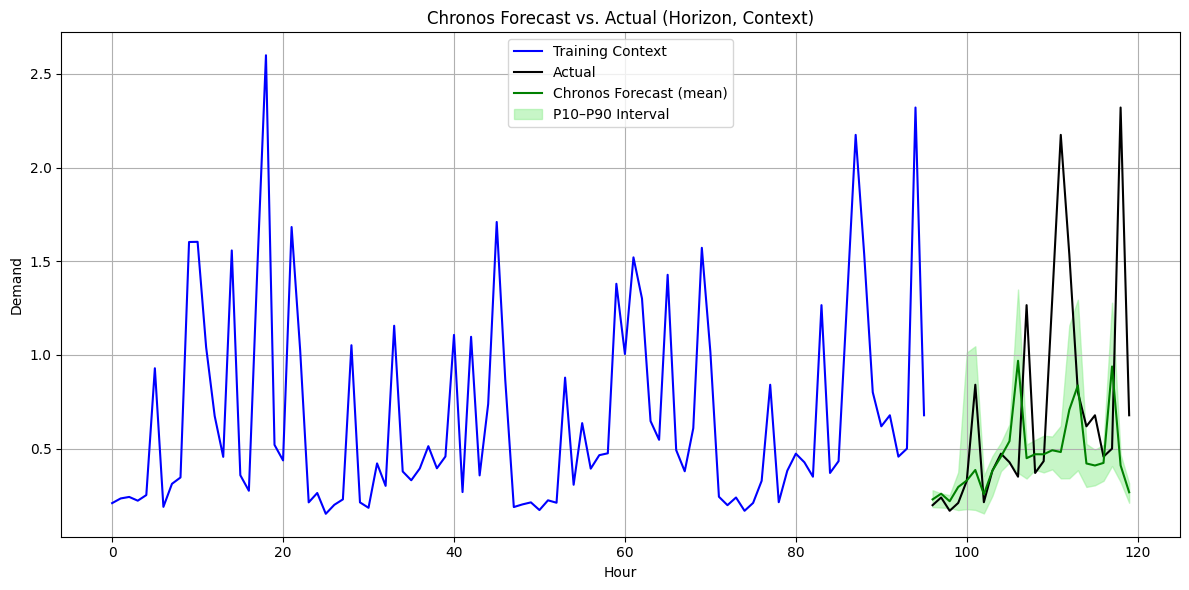

Chronos Forecast Accuracy:
MAE:  0.3755
MAPE: 41.00%


In [ ]:
# === CONFIG ===
plot_context_length = 96         # Show last 96 hours of context
prediction_length = 24          # Forecast horizon

# === CONVERT TO NUMPY ARRAYS ===
context_np = context_tensor.detach().cpu().numpy()
mean_np = mean[0].detach().cpu().numpy()
p10 = quantiles[0, :, 0].detach().cpu().numpy()
p90 = quantiles[0, :, 2].detach().cpu().numpy()

# === GROUND TRUTH ===
# Ensure y_test only contains the last 24 values of the full series
y_test = series[-prediction_length:]

# === CREATE X AXES ===
context_display = context_np[-plot_context_length:]  # show only last 96 hours
x_context = np.arange(plot_context_length)
x_forecast = np.arange(plot_context_length, plot_context_length + prediction_length)

# === PLOT ===
plt.figure(figsize=(12, 6))

# Plot last hours of context
plt.plot(x_context, context_display, label='Training Context', color='blue')

# Plot actual values
plt.plot(x_forecast, y_test, label='Actual', color='black')

# Plot Chronos mean forecast
plt.plot(x_forecast, mean_np, label='Chronos Forecast (mean)', color='green')

# Plot P10–P90 interval
plt.fill_between(x_forecast, p10, p90, color='lightgreen', alpha=0.5, label='P10–P90 Interval')

# Styling
plt.title("Chronos Forecast vs. Actual (Horizon, Context)")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

chronos_pred = mean[0].detach().cpu().numpy()


# Compute metrics

mae = mean_absolute_error(y_test, chronos_pred)
mape = np.mean(np.abs((y_test - chronos_pred) / y_test)) * 100

# Display
print(f"Chronos Forecast Accuracy:")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")